# Bank Customer Churn: Exploratory Data Analysis

**Dataset:** 10,000 retail banking customers across France, Germany, and Spain
**Question:** Who is leaving the bank, and is there a pattern we can act on?

**Headline finding:** 1 in 5 customers has churned. The loss is not spread evenly.
It concentrates in three places: customers aged 41 to 60, customers holding 3 or more
products, and customers in Germany. Meanwhile the variables a bank might *expect* to
predict churn (credit score, salary, tenure, owning a credit card) are essentially flat.

Read the section summaries in bold if you are skimming.

## 0. Setup and load

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.width", 150)
pd.set_option("display.max_columns", 30)
sns.set_theme(style="whitegrid")
plt.rcParams["figure.dpi"] = 110

df = pd.read_csv(r"C:\Users\angelo\Downloads\Bank+Customer+Churn\Bank_Churn.csv")
df.shape

(10000, 13)

## 1. First look

Before analysing anything, check the basics: what columns exist, what types they are,
whether there are missing values, and whether rows are duplicated. Skipping this step is
the most common way to build an analysis on top of a broken assumption.

In [6]:
df.head()

,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 13 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   CustomerId       10000 non-null  int64  
 1   Surname          10000 non-null  object 
 2   CreditScore      10000 non-null  int64  
 3   Geography        10000 non-null  object 
 4   Gender           10000 non-null  object 
 5   Age              10000 non-null  int64  
 6   Tenure           10000 non-null  int64  
 7   Balance          10000 non-null  float64
 8   NumOfProducts    10000 non-null  int64  
 9   HasCrCard        10000 non-null  int64  
 10  IsActiveMember   10000 non-null  int64  
 11  EstimatedSalary  10000 non-null  float64
 12  Exited           10000 non-null  int64  
dtypes: float64(2), int64(8), object(3)
memory usage: 1015.8+ KB


In [8]:
print("Missing values per column:")
print(df.isna().sum())
print()
print("Fully duplicated rows:", df.duplicated().sum())
print("Duplicated CustomerIds:", df.CustomerId.duplicated().sum())

Missing values per column:
CustomerId         0
Surname            0
CreditScore        0
Geography          0
Gender             0
Age                0
Tenure             0
Balance            0
NumOfProducts      0
HasCrCard          0
IsActiveMember     0
EstimatedSalary    0
Exited             0
dtype: int64

Fully duplicated rows: 0
Duplicated CustomerIds: 0


**Clean bill of health.** No missing values, no duplicate rows, and `CustomerId` is unique,
so every row is one customer. That is unusual for real data and worth saying out loud:
this dataset has been pre-cleaned, so the cleaning stage is short and we can go straight
to exploring.

Two columns are identifiers rather than features. `CustomerId` and `Surname` describe *who*
the customer is, not *what they do*, so they get excluded from any analysis of behaviour.

In [9]:
ID_COLS = ["CustomerId", "Surname"]
TARGET = "Exited"
features = [c for c in df.columns if c not in ID_COLS + [TARGET]]
features

['CreditScore',
 'Geography',
 'Gender',
 'Age',
 'Tenure',
 'Balance',
 'NumOfProducts',
 'HasCrCard',
 'IsActiveMember',
 'EstimatedSalary']

## 2. The target variable: how much churn are we talking about?

In [10]:
churn_counts = df[TARGET].value_counts().sort_index()
churn_rate = df[TARGET].mean()

print(churn_counts.rename({0: "Stayed", 1: "Churned"}))
print()
print(f"Overall churn rate: {churn_rate:.1%}")

Exited
Stayed     7963
Churned    2037
Name: count, dtype: int64

Overall churn rate: 20.4%


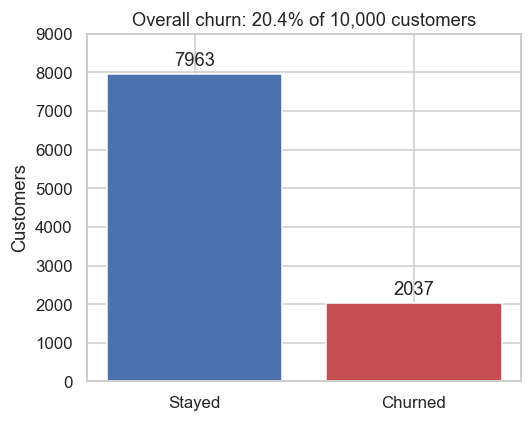

In [11]:
fig, ax = plt.subplots(figsize=(5, 4))
bars = ax.bar(["Stayed", "Churned"], churn_counts.values, color=["#4c72b0", "#c44e52"])
ax.bar_label(bars, fmt="%d", padding=3)
ax.set_ylabel("Customers")
ax.set_title(f"Overall churn: {churn_rate:.1%} of 10,000 customers")
ax.set_ylim(0, 9000)
plt.tight_layout()
plt.show()

**20.4% churn, and the classes are imbalanced roughly 4 to 1.**

That imbalance matters for two reasons. First, any comparison from here on has to be a
churn *rate* within a group, not a raw count, or large groups will always look worse.
Second, if this analysis were ever extended into a predictive model, a model that predicted
"nobody churns" would be 79.6% accurate while being completely useless. Accuracy would be
the wrong metric.

We use `.mean()` on the 0/1 target throughout as a shortcut: the mean of a binary column
*is* the rate.

## 3. Numeric variables: distributions first

Look at the shape of each numeric variable before relating it to anything else. Skew,
spikes, and floors are the things that break later analysis if you do not spot them now.

In [12]:
num_cols = ["CreditScore", "Age", "Tenure", "Balance", "EstimatedSalary"]
df[num_cols].describe().round(1)

,CreditScore,Age,Tenure,Balance,EstimatedSalary
count,10000.0,10000.0,10000.0,10000.0,10000.0
mean,650.5,38.9,5.0,76485.9,100090.2
std,96.7,10.5,2.9,62397.4,57510.5
min,350.0,18.0,0.0,0.0,11.6
25%,584.0,32.0,3.0,0.0,51002.1
50%,652.0,37.0,5.0,97198.5,100193.9
75%,718.0,44.0,7.0,127644.2,149388.2
max,850.0,92.0,10.0,250898.1,199992.5


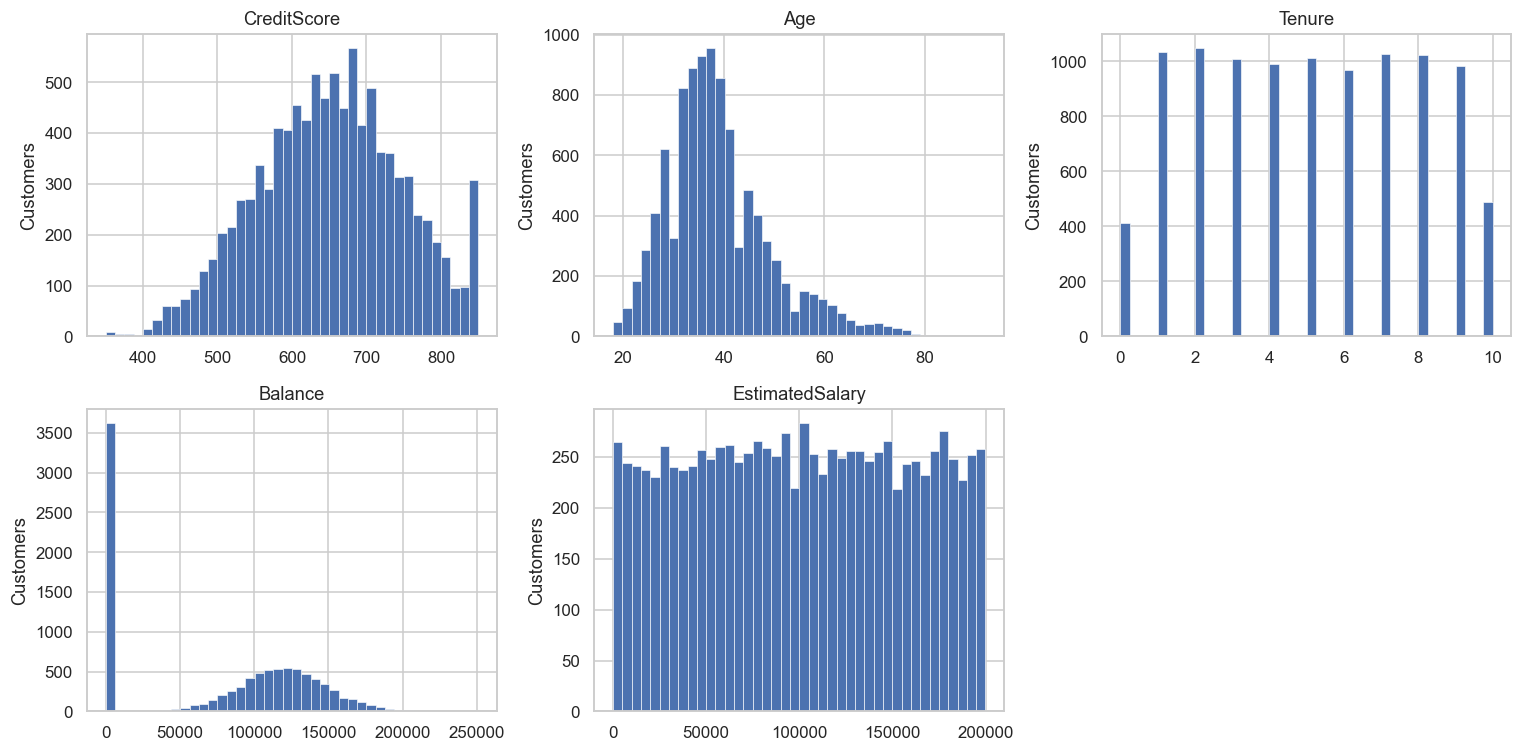

In [13]:
fig, axes = plt.subplots(2, 3, figsize=(14, 7))
for ax, col in zip(axes.flat, num_cols):
    ax.hist(df[col], bins=40, color="#4c72b0", edgecolor="white", linewidth=0.4)
    ax.set_title(col)
    ax.set_ylabel("Customers")
axes.flat[-1].axis("off")
plt.tight_layout()
plt.show()

Three things stand out:

- **`Age` is right-skewed.** Most customers are in their 30s, with a long tail up to 92.
  A mean of 38.9 hides that tail, so age needs to be bucketed rather than treated as a
  single average.
- **`Balance` has a huge spike at exactly zero.** Around 36% of customers have a zero
  balance. That is not a normal distribution with a low end, it is two different
  populations stacked in one column. Flagged here and investigated in section 7.
- **`CreditScore` and `EstimatedSalary` look unremarkable.** Credit score is roughly normal
  around 650, salary is close to uniform from 0 to 200k. A uniform salary distribution is a
  hint that the column may be synthetic filler rather than real observed data.

## 4. Which categories churn? A first pass

Rather than eyeballing five charts one at a time, loop over the categorical and low-cardinality
columns and compute the churn rate within each level. This is the single most useful
`groupby` pattern in an EDA like this, so it is worth writing once and reusing.

In [14]:
def churn_by(col, data=df):
    """Churn rate and customer count for each level of a column."""
    out = (data.groupby(col)[TARGET]
                .agg(customers="size", churned="sum", churn_rate="mean")
                .sort_values("churn_rate", ascending=False))
    out["churn_rate"] = (out["churn_rate"] * 100).round(1)
    return out

cat_cols = ["Geography", "Gender", "NumOfProducts", "HasCrCard", "IsActiveMember", "Tenure"]
for col in cat_cols:
    print(f"--- {col} ---")
    print(churn_by(col))
    print()

--- Geography ---
           customers  churned  churn_rate
Geography                                
Germany         2509      814        32.4
Spain           2477      413        16.7
France          5014      810        16.2

--- Gender ---
        customers  churned  churn_rate
Gender                                
Female       4543     1139        25.1
Male         5457      898        16.5

--- NumOfProducts ---
               customers  churned  churn_rate
NumOfProducts                                
4                     60       60       100.0
3                    266      220        82.7
1                   5084     1409        27.7
2                   4590      348         7.6

--- HasCrCard ---
           customers  churned  churn_rate
HasCrCard                                
0               2945      613        20.8
1               7055     1424        20.2

--- IsActiveMember ---
                customers  churned  churn_rate
IsActiveMember                             

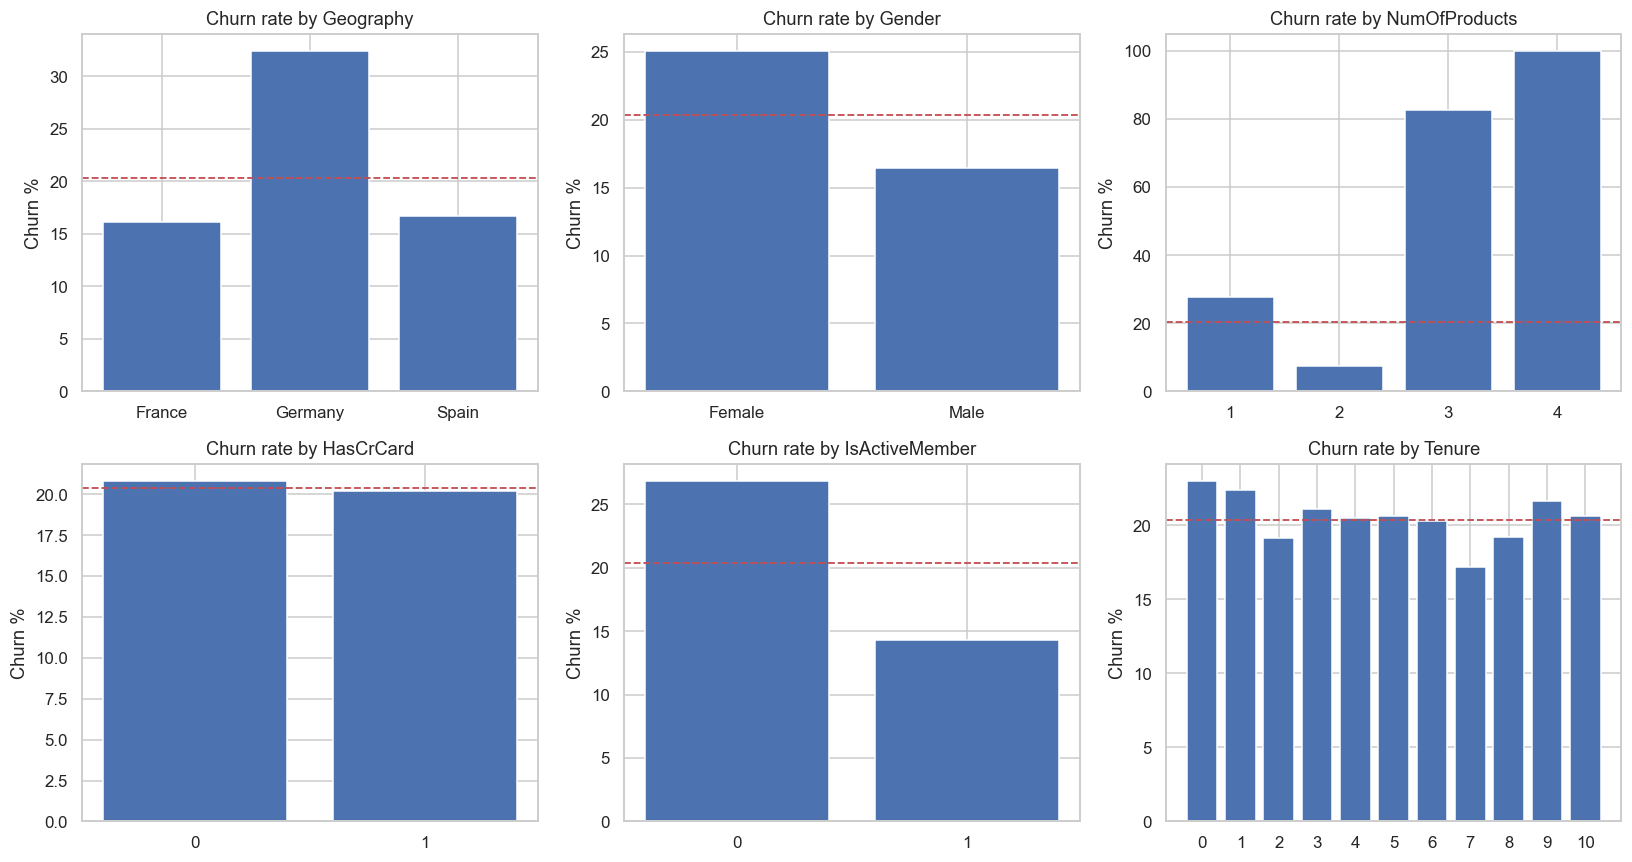

In [15]:
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
for ax, col in zip(axes.flat, cat_cols):
    rates = df.groupby(col)[TARGET].mean() * 100
    ax.bar(rates.index.astype(str), rates.values, color="#4c72b0")
    ax.axhline(churn_rate * 100, color="#c44e52", linestyle="--", linewidth=1.2)
    ax.set_title(f"Churn rate by {col}")
    ax.set_ylabel("Churn %")
plt.tight_layout()
plt.show()

The dashed red line is the 20.4% baseline. Bars above it are groups losing customers faster
than the bank as a whole.

**Four columns move, two do not.** `NumOfProducts`, `Geography`, `Gender`, and
`IsActiveMember` all produce real separation. `HasCrCard` and `Tenure` are flat, which is a
finding in itself and gets its own section at the end.

The next three sections dig into the biggest movers.

## 5. Age is the strongest signal in the dataset

Age did not appear above because it is continuous. Bucketing it into bands makes the
pattern visible.

In [32]:
bands = [17, 30, 40, 50, 60, 100]
labels = ["18-30", "31-40", "41-50", "51-60", "61+"]
df["AgeBand"] = pd.cut(df["Age"], bins=bands, labels=labels)

age_summary = churn_by("AgeBand").reindex(labels)
age_summary

C:\Users\angelo\AppData\Local\Temp\ipykernel_39368\4144938880.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  out = (data.groupby(col)[TARGET]


,customers,churned,churn_rate
AgeBand,,,
18-30,1968,148,7.5
31-40,4451,538,12.1
41-50,2320,788,34.0
51-60,797,448,56.2
61+,464,115,24.8


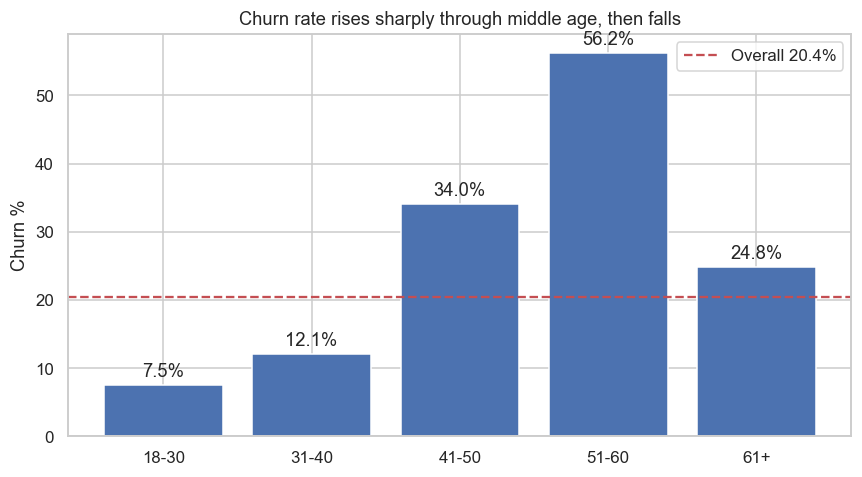

In [17]:
fig, ax = plt.subplots(figsize=(8, 4.5))
bars = ax.bar(age_summary.index, age_summary["churn_rate"], color="#4c72b0")
ax.bar_label(bars, fmt="%.1f%%", padding=3)
ax.axhline(churn_rate * 100, color="#c44e52", linestyle="--", label="Overall 20.4%")
ax.set_ylabel("Churn %")
ax.set_title("Churn rate rises sharply through middle age, then falls")
ax.legend()
plt.tight_layout()
plt.show()

In [18]:
mid_age = df[df.Age.between(41, 60)]
share = mid_age[TARGET].sum() / df[TARGET].sum()
print(f"Customers aged 41-60: {len(mid_age):,} ({len(mid_age)/len(df):.1%} of the book)")
print(f"Share of ALL churners who are 41-60: {share:.1%}")

Customers aged 41-60: 3,117 (31.2% of the book)
Share of ALL churners who are 41-60: 60.7%


**Churn climbs from 7.5% among under-30s to 56.2% among 51 to 60 year olds, then drops
back for the over-60s.**

This is the finding with the most money attached. Customers aged 41 to 60 are only 31% of
the customer base but account for 61% of everyone who left. A retention effort aimed at
this band reaches most of the problem.

The drop after 60 is worth a caveat rather than a confident explanation. It could be
genuine (retirees are stickier), or it could be a small-sample effect, since only 464
customers are in that band. Either way, do not build a story on it without more data.

## 6. Number of products: a cliff, not a slope

In [19]:
prod = churn_by("NumOfProducts").sort_index()
prod

,customers,churned,churn_rate
NumOfProducts,,,
1,5084,1409,27.7
2,4590,348,7.6
3,266,220,82.7
4,60,60,100.0


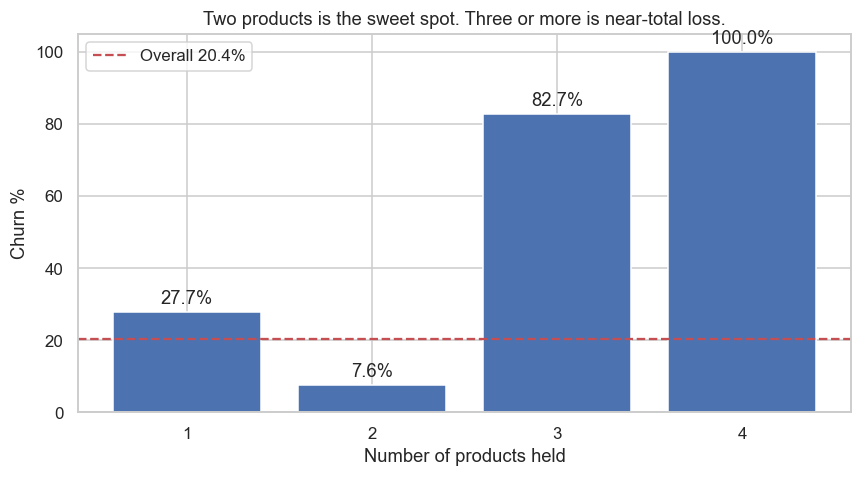

In [20]:
fig, ax = plt.subplots(figsize=(8, 4.5))
bars = ax.bar(prod.index.astype(str), prod["churn_rate"], color="#4c72b0")
ax.bar_label(bars, fmt="%.1f%%", padding=3)
ax.axhline(churn_rate * 100, color="#c44e52", linestyle="--", label="Overall 20.4%")
ax.set_xlabel("Number of products held")
ax.set_ylabel("Churn %")
ax.set_title("Two products is the sweet spot. Three or more is near-total loss.")
ax.legend()
plt.tight_layout()
plt.show()

In [21]:
heavy = df[df.NumOfProducts >= 3]
print(f"Customers with 3+ products: {len(heavy):,} ({len(heavy)/len(df):.1%} of the book)")
print(f"Of them, churned: {heavy[TARGET].sum():,} ({heavy[TARGET].mean():.1%})")
print(f"Share of ALL churners: {heavy[TARGET].sum()/df[TARGET].sum():.1%}")

Customers with 3+ products: 326 (3.3% of the book)
Of them, churned: 280 (85.9%)
Share of ALL churners: 13.7%


**The relationship is not monotonic, which is why it is interesting.** Churn falls from
27.7% at one product to 7.6% at two, then jumps to 82.7% at three and 100% at four.

Every single customer holding four products left. That is the kind of number that should
make you suspicious before it makes you excited, so state the two possible readings:

1. **Real business signal.** Customers are being cross-sold products that do not suit them,
   and the third product is a symptom of a struggling relationship rather than a deepening one.
2. **Artefact of how the data was built.** The dataset may have been generated with this
   pattern baked in.

An analyst at the bank would resolve this by asking *when* the third product was opened
relative to the exit date. We cannot, because there are no dates here. So the honest
framing is: flag it, do not over-claim it.

**Size matters too.** Only 326 customers hold 3 or more products, so even at an 86% churn
rate they are 14% of total churn. The rate is dramatic; the volume is not. Compare that to
the age finding, which is 61% of churn. If you can only fix one thing, fix age.

## 7. Geography, and a data quality catch

In [22]:
churn_by("Geography")

,customers,churned,churn_rate
Geography,,,
Germany,2509,814,32.4
Spain,2477,413,16.7
France,5014,810,16.2


In [23]:
geo_gender = df.pivot_table(index="Geography", columns="Gender",
                            values=TARGET, aggfunc="mean").round(3) * 100
geo_gender

Gender,Female,Male
Geography,,
France,20.3,12.7
Germany,37.6,27.8
Spain,21.2,13.1


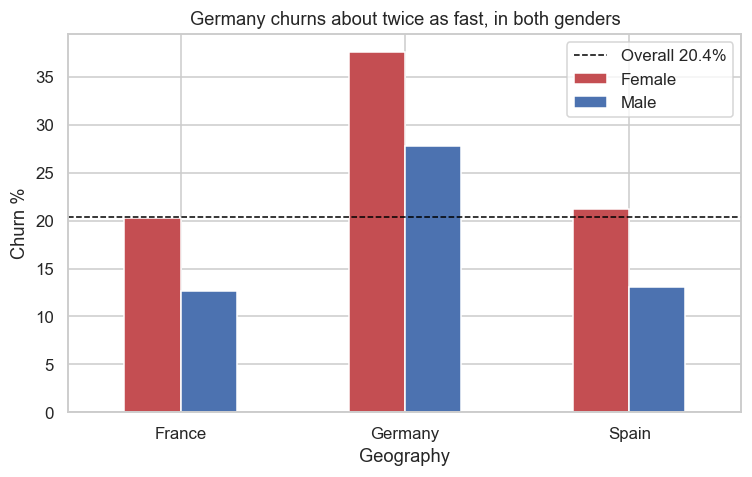

In [24]:
fig, ax = plt.subplots(figsize=(7, 4.5))
geo_gender.plot(kind="bar", ax=ax, color=["#c44e52", "#4c72b0"], rot=0)
ax.axhline(churn_rate * 100, color="black", linestyle="--", linewidth=1, label="Overall 20.4%")
ax.set_ylabel("Churn %")
ax.set_title("Germany churns about twice as fast, in both genders")
ax.legend(title="")
plt.tight_layout()
plt.show()

**Germany churns at 32.4% against roughly 16% in France and Spain.** Women churn more than
men (25.1% vs 16.5%), and the two effects stack rather than explain each other: German women
churn at 37.6%, French men at 12.7%.

Before concluding "Germany has a retention problem", check whether the German records
differ structurally from the others. This is the step that separates an analyst from
someone making charts.

In [25]:
geo_check = df.groupby("Geography").agg(
    customers=("CustomerId", "size"),
    mean_balance=("Balance", "mean"),
    pct_zero_balance=("Balance", lambda s: (s == 0).mean() * 100),
    mean_age=("Age", "mean"),
).round(1)
geo_check

,customers,mean_balance,pct_zero_balance,mean_age
Geography,,,,
France,5014,62092.6,48.2,38.5
Germany,2509,119730.1,0.0,39.8
Spain,2477,61818.1,48.4,38.9


**Caught one.** Roughly 48% of French and Spanish customers have a zero balance, and
**zero percent** of German customers do. That is not plausible customer behaviour, it is a
difference in how the data was recorded. Germany's higher average balance is a direct
consequence.

This matters for interpretation. Any conclusion of the form "high-balance customers churn
more" is partly just "German customers churn more", because balance and geography are
entangled by a recording artefact. Worth checking directly:

In [26]:
df["ZeroBalance"] = df.Balance == 0
print(churn_by("ZeroBalance"))
print()
print("Within France and Spain only:")
print(churn_by("ZeroBalance", df[df.Geography != "Germany"]))

             customers  churned  churn_rate
ZeroBalance                                
False             6383     1537        24.1
True              3617      500        13.8

Within France and Spain only:
             customers  churned  churn_rate
ZeroBalance                                
False             3874      723        18.7
True              3617      500        13.8


Overall, zero-balance customers look *safer* (13.8% vs 24.1%). But restricted to France and
Spain, where both types of record exist, the gap narrows considerably. Most of the apparent
balance effect was geography wearing a disguise.

**Takeaway:** report Germany as the finding. Treat balance as contaminated and do not lean
on it.

## 8. Activity status: the one lever the bank actually controls

In [27]:
churn_by("IsActiveMember")

,customers,churned,churn_rate
IsActiveMember,,,
0,4849,1302,26.9
1,5151,735,14.3


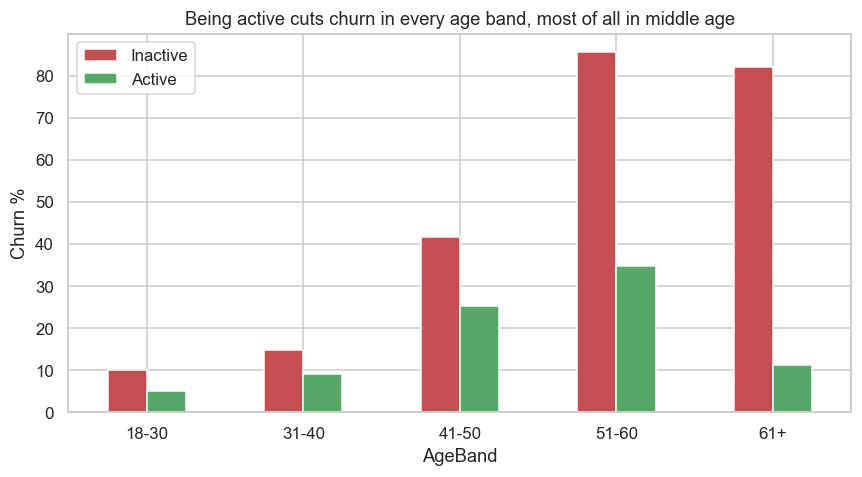

,Inactive,Active
AgeBand,,
18-30,10.1,5.1
31-40,14.9,9.2
41-50,41.6,25.4
51-60,85.7,34.7
61+,82.0,11.2


In [28]:
active_age = (df.pivot_table(index="AgeBand", columns="IsActiveMember",
                             values=TARGET, aggfunc="mean", observed=True) * 100).round(1)
active_age.columns = ["Inactive", "Active"]

fig, ax = plt.subplots(figsize=(8, 4.5))
active_age.plot(kind="bar", ax=ax, color=["#c44e52", "#55a868"], rot=0)
ax.set_ylabel("Churn %")
ax.set_title("Being active cuts churn in every age band, most of all in middle age")
ax.legend(title="")
plt.tight_layout()
plt.show()

active_age

**Inactive members churn at 26.9%, active members at 14.3%.**

This is the most actionable variable in the dataset because it is the only one the bank can
change. You cannot make a customer younger or move them out of Germany, but you can run a
re-engagement campaign.

The size of the effect is biggest exactly where the problem is worst. Among 51 to 60 year
olds, inactive customers churn far harder than active ones in the same band.

One honest caveat: this is correlation, and the causal arrow may run backwards. A customer
who has mentally decided to leave stops using the account first, so inactivity may be an
early *symptom* of churn rather than a cause of it. That still makes it useful, because it
means inactivity works as an early warning flag even if re-engagement campaigns do not fix
the underlying reason.

## 9. What does NOT predict churn

Negative results are worth reporting. They stop the business spending money on the wrong
segmentation.

In [29]:
for col in ["CreditScore", "EstimatedSalary", "Tenure"]:
    means = df.groupby(TARGET)[col].mean().round(1)
    print(f"{col:18s} stayed: {means[0]:>10,.1f}   churned: {means[1]:>10,.1f}")
print()
print(churn_by("HasCrCard"))

CreditScore        stayed:      651.9   churned:      645.4
EstimatedSalary    stayed:   99,738.4   churned:  101,465.7
Tenure             stayed:        5.0   churned:        4.9

           customers  churned  churn_rate
HasCrCard                                
0               2945      613        20.8
1               7055     1424        20.2


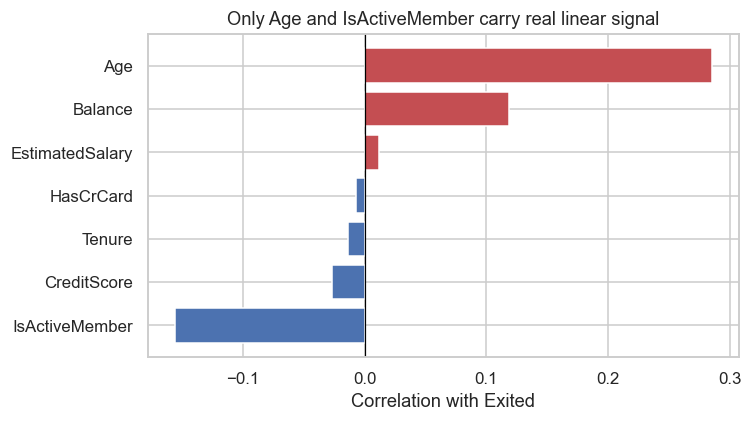

IsActiveMember    -0.156
CreditScore       -0.027
Tenure            -0.014
HasCrCard         -0.007
EstimatedSalary    0.012
Balance            0.119
Age                0.285
Name: Exited, dtype: float64

In [30]:
corr = df[num_cols + ["HasCrCard", "IsActiveMember", TARGET]].corr()[TARGET].drop(TARGET)
corr = corr.sort_values()

fig, ax = plt.subplots(figsize=(7, 4))
colors = ["#c44e52" if v > 0 else "#4c72b0" for v in corr.values]
ax.barh(corr.index, corr.values, color=colors)
ax.axvline(0, color="black", linewidth=0.8)
ax.set_xlabel("Correlation with Exited")
ax.set_title("Only Age and IsActiveMember carry real linear signal")
plt.tight_layout()
plt.show()

corr.round(3)

**Four variables are essentially noise:**

- **CreditScore:** 651.9 for stayers vs 645.4 for churners. A 6-point gap on a 350 to 850
  scale is nothing.
- **EstimatedSalary:** churners actually earn marginally *more*. The difference is well
  inside random variation.
- **Tenure:** flat at roughly 20% across all 10 years. Customers are not leaving because
  they got bored over time.
- **HasCrCard:** 20.8% vs 20.2%. No effect at all.

Note the correlation chart understates `NumOfProducts` badly, because that relationship is
U-shaped and correlation only measures straight lines. This is a good reminder not to rely
on a correlation matrix alone to decide what matters.

## 10. Summary and recommendations

**The bank loses 1 in 5 customers. Three segments explain most of it.**

| Finding | Churn rate | Size of group | Share of all churners |
|---|---|---|---|
| Aged 41 to 60 | 34% to 56% | 31% of customers | **61%** |
| Inactive members | 26.9% | 48% of customers | 64% |
| Germany | 32.4% | 25% of customers | 40% |
| Holding 3+ products | 86% | 3% of customers | 14% |

**Recommendations, in order of expected impact:**

1. **Target retention at customers aged 41 to 60.** This is where the volume is. Everything
   else is a smaller prize.
2. **Use inactivity as an early warning flag.** It is the only variable the bank directly
   controls, and it roughly halves churn. Build a trigger on it: inactive plus aged 41 to 60
   is the highest-value list the bank could pull tomorrow.
3. **Investigate the German book specifically.** A 2x churn rate that survives controlling
   for gender is a market or product problem, not a customer-mix problem.
4. **Audit the cross-sell process.** Almost everyone with 3 or more products left. Worth
   understanding before it scales, even though the group is currently small.
5. **Stop segmenting on credit score, salary, tenure, or card ownership.** They do not
   separate churners from stayers in this data.

**Caveats, stated up front rather than buried:**

- No dates anywhere. We cannot tell whether a third product was opened before or after the
  customer started disengaging, so the products finding is a correlation with an unknown
  direction.
- The `Balance` column is contaminated by a recording difference between Germany and the
  other two countries. Conclusions about balance are unreliable.
- `EstimatedSalary` is near-uniform, which suggests it may be synthetic rather than observed.
- All findings are associations from a single snapshot. Nothing here establishes cause.

**Obvious next steps:** bring in transaction-level and dated data to establish sequence,
then build a churn probability model. Given the 4:1 class imbalance, evaluate it on
precision, recall, and ROC AUC rather than accuracy.